# Segmentierungspipeline – Alle Forster-Handschriften

Pipeline: Deskew → YOLO-Layoutanalyse → Kraken-Zeilensegmentierung → Line-Crops → JSON-Manifest

**Eingabe:** `data/forster_all/forster{1..6}/*.jpg` (923 Seiten)  
**Ausgabe:** `data/all_line_crops/<page_id>/`, `data/all_manifests/`  
**Namensschema:** `B1_P012_L01.jpg`

In [1]:
import os
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
from tqdm import tqdm

from skimage.filters import threshold_sauvola
from skimage.color import rgb2gray
from scipy.ndimage import rotate as nd_rotate

warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR     = REPO_ROOT / 'data/forster_all'
CROPS_DIR    = REPO_ROOT / 'data/all_line_crops'
MANIFEST_DIR = REPO_ROOT / 'data/all_manifests'
CROPS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# --- Parameter (bei 300 DPI) ---
SKEW_THRESHOLD_DEG = 0.5
PAD_TOP_PX         = 18
PAD_BOTTOM_PX      = 12
SAUVOLA_WIN_SIZE   = 51
SAUVOLA_K          = 0.15

YOLO_TEXT_CLASSES  = {'plain text', 'title'}
YOLO_CONF          = 0.35

# Alle JPEGs aus allen forster-Unterordnern, sortiert
JPEG_FILES = sorted(DATA_DIR.rglob('*.jpg'))
print(f'Gefundene Seiten: {len(JPEG_FILES)}')
for subdir in sorted(set(f.parent.name for f in JPEG_FILES)):
    count = sum(1 for f in JPEG_FILES if f.parent.name == subdir)
    print(f'  {subdir}: {count} Dateien')

Gefundene Seiten: 923
  forster1: 132 Dateien
  forster2: 164 Dateien
  forster3: 151 Dateien
  forster4: 165 Dateien
  forster5: 155 Dateien
  forster6: 156 Dateien


In [2]:
from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10

YOLO_MODEL_REPO = 'juliozhao/DocLayout-YOLO-DocStructBench'
YOLO_MODEL_FILE = 'doclayout_yolo_docstructbench_imgsz1024.pt'

try:
    model_path = hf_hub_download(repo_id=YOLO_MODEL_REPO, filename=YOLO_MODEL_FILE)
    yolo_model = YOLOv10(model_path)
    YOLO_AVAILABLE = True
    print(f'DocLayout-YOLO geladen: {YOLO_MODEL_FILE}')
except Exception as e:
    YOLO_AVAILABLE = False
    print(f'YOLO nicht verfügbar: {e}')
    print('Fallback: gesamte Seitenfläche als Textregion.')

DocLayout-YOLO geladen: doclayout_yolo_docstructbench_imgsz1024.pt


In [3]:
from kraken import blla
from kraken.lib import models as kraken_models

KRAKEN_MODEL = None  # None → blla Default-Modell
print('Kraken geladen.')

Kraken geladen.


In [4]:
def estimate_skew(gray: np.ndarray) -> float:
    """Schätzt Schrägstellungswinkel via HoughLinesP auf fast-horizontalen Linien."""
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100,
                             minLineLength=100, maxLineGap=10)
    if lines is None:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 != x1:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if abs(angle) < 10:
                angles.append(angle)
    return float(np.median(angles)) if angles else 0.0


def deskew_image(pil_img: Image.Image, angle: float) -> Image.Image:
    """Dreht ein PIL-Bild um angle Grad; füllt freie Ecken mit Weiß."""
    if abs(angle) <= SKEW_THRESHOLD_DEG:
        return pil_img
    arr = np.array(pil_img)
    rotated = nd_rotate(arr, angle, reshape=False, cval=255, mode='constant')
    return Image.fromarray(rotated.astype(np.uint8))


def detect_text_regions(pil_img: Image.Image) -> list[dict]:
    """Erkennt Textregionen via YOLO; Fallback: eine Region über die gesamte Seite."""
    W, H = pil_img.size
    if not YOLO_AVAILABLE:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]
    results = yolo_model.predict(pil_img, imgsz=1024, conf=YOLO_CONF, verbose=False)
    regions = []
    for box in results[0].boxes:
        cls_name = yolo_model.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        regions.append({'bbox': [x1, y1, x2, y2], 'label': cls_name, 'conf': conf})
    text_regions = [r for r in regions if r['label'] in YOLO_TEXT_CLASSES]
    if not text_regions:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]
    return text_regions


def segment_page(pil_img: Image.Image, regions: list[dict]) -> list:
    """Führt Kraken blla-Segmentierung durch; gibt alle Lines mit Vollbild-Koordinaten zurück."""
    all_lines = []
    W, H = pil_img.size
    for region in regions:
        x1, y1, x2, y2 = region['bbox']
        crop = pil_img.crop((x1, y1, x2, y2))
        seg = blla.segment(crop, model=KRAKEN_MODEL)
        for line in seg.lines:
            line.baseline = [(px + x1, py + y1) for px, py in line.baseline]
            line.boundary = [(px + x1, py + y1) for px, py in line.boundary]
            line._region_label = region['label']
            all_lines.append(line)
    return all_lines


def extract_line_crops(
    pil_img: Image.Image,
    lines: list,
    page_id: str,
    out_dir: Path,
    pad_top: int = PAD_TOP_PX,
    pad_bottom: int = PAD_BOTTOM_PX,
) -> list[dict]:
    """
    Schneidet Zeilenbilder aus und speichert sie.
    Namensschema: <page_id>_L01.jpg  (z.B. B1_P012_L01.jpg)
    """
    W, H = pil_img.size
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []

    for idx, line in enumerate(lines):
        if not line.boundary:
            continue

        pts = np.array(line.boundary, dtype=int)
        x1 = max(0, int(pts[:, 0].min()))
        x2 = min(W, int(pts[:, 0].max()))
        y1 = max(0, int(pts[:, 1].min()) - pad_top)
        y2 = min(H, int(pts[:, 1].max()) + pad_bottom)

        if x2 - x1 < 10 or y2 - y1 < 5:
            continue

        median_y = float(np.median(pts[:, 1]))
        expanded = [
            (x, max(0, y - pad_top) if y <= median_y else min(H, y + pad_bottom))
            for x, y in line.boundary
        ]

        mask = Image.new('L', (W, H), 0)
        ImageDraw.Draw(mask).polygon(expanded, fill=255)

        img_crop  = pil_img.crop((x1, y1, x2, y2))
        mask_crop = mask.crop((x1, y1, x2, y2))

        result = Image.new('RGB', img_crop.size, (255, 255, 255))
        result.paste(img_crop, mask=mask_crop)

        # Namensschema: B1_P012_L01.jpg (page_id enthält bereits kein _P_)
        line_id  = f'{page_id}_L{idx+1:02d}'
        filename = f'{line_id}.jpg'
        result.save(out_dir / filename, quality=95)

        records.append({
            'line_id'     : line_id,
            'line_image'  : str((out_dir / filename).relative_to(REPO_ROOT)),
            'bbox'        : [x1, y1, x2 - x1, y2 - y1],
            'baseline'    : [list(p) for p in line.baseline],
            'boundary'    : [list(p) for p in line.boundary],
            'region_label': getattr(line, '_region_label', 'text'),
        })

    return records


def build_page_manifest(
    page_id: str,
    source_image: Path,
    skew_angle: float,
    regions: list[dict],
    line_records: list[dict],
) -> dict:
    return {
        'page_id'       : page_id,
        'source_image'  : str(source_image.relative_to(REPO_ROOT)),
        'image_size'    : list(Image.open(source_image).size),
        'skew_angle_deg': round(skew_angle, 3),
        'deskewed'      : abs(skew_angle) > SKEW_THRESHOLD_DEG,
        'n_regions'     : len(regions),
        'n_lines'       : len(line_records),
        'regions'       : [{'label': r['label'], 'bbox': r['bbox'], 'conf': round(r['conf'], 3)}
                           for r in regions],
        'lines'         : line_records,
    }


def save_page_manifest(manifest: dict, out_dir: Path):
    path = out_dir / f"{manifest['page_id']}.json"
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    return path


def save_global_manifest(page_manifests: list[dict], out_dir: Path):
    summary = [
        {
            'page_id'       : m['page_id'],
            'source_image'  : m['source_image'],
            'n_lines'       : m['n_lines'],
            'skew_angle_deg': m['skew_angle_deg'],
            'manifest_path' : str(out_dir / f"{m['page_id']}.json"),
        }
        for m in page_manifests
    ]
    global_path = out_dir / 'manifest.json'
    with open(global_path, 'w', encoding='utf-8') as f:
        json.dump(
            {'pages': summary, 'total_lines': sum(s['n_lines'] for s in summary)},
            f, ensure_ascii=False, indent=2,
        )
    return global_path


print('Funktionen definiert.')

Funktionen definiert.


---
## Pipeline – alle Seiten verarbeiten

Bereits verarbeitete Seiten (Manifest vorhanden) werden übersprungen – der Lauf ist damit resumable.

In [5]:
all_manifests = []
skipped = 0

for jpg in tqdm(JPEG_FILES, desc='Seiten verarbeiten'):
    page_id = jpg.stem  # z.B. B1_P012

    # Bereits verarbeitete Seiten überspringen
    manifest_path = MANIFEST_DIR / f'{page_id}.json'
    if manifest_path.exists():
        with open(manifest_path) as f:
            all_manifests.append(json.load(f))
        skipped += 1
        continue

    # 1. Laden
    pil_img = Image.open(jpg).convert('RGB')

    # 2. Deskew
    gray = np.array(pil_img.convert('L'))
    angle = estimate_skew(gray)
    pil_img = deskew_image(pil_img, angle)

    # 3. YOLO Layoutanalyse
    regions = detect_text_regions(pil_img)

    # 4. Kraken Zeilensegmentierung
    lines = segment_page(pil_img, regions)

    # 5. Zeilenbilder speichern  →  B1_P012_L01.jpg
    out_dir = CROPS_DIR / page_id
    line_records = extract_line_crops(pil_img, lines, page_id, out_dir)

    # 6. Seitenmanifest
    manifest = build_page_manifest(page_id, jpg, angle, regions, line_records)
    save_page_manifest(manifest, MANIFEST_DIR)
    all_manifests.append(manifest)

    tqdm.write(f'{page_id}: {len(line_records)} Zeilen, Skew {angle:+.2f}°')

# 7. Gesamtmanifest
global_path = save_global_manifest(all_manifests, MANIFEST_DIR)
print(f'\nGesamtmanifest gespeichert: {global_path}')
print(f'Übersprungen (bereits verarbeitet): {skipped}')

Seiten verarbeiten:   0%|          | 1/923 [00:08<2:09:02,  8.40s/it]

B1_P012: 13 Zeilen, Skew +1.09°


Seiten verarbeiten:   0%|          | 2/923 [00:18<2:21:09,  9.20s/it]

B1_P014: 30 Zeilen, Skew -0.27°


Seiten verarbeiten:   0%|          | 3/923 [00:27<2:20:54,  9.19s/it]

...

B6_P220: 36 Zeilen, Skew +0.00°


Seiten verarbeiten: 100%|█████████▉| 922/923 [2:57:33<00:10, 10.75s/it]

B6_P221: 34 Zeilen, Skew +0.00°


Seiten verarbeiten: 100%|██████████| 923/923 [2:57:39<00:00, 11.55s/it]

B6_P234: 4 Zeilen, Skew +0.00°

Gesamtmanifest gespeichert: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/all_manifests/manifest.json
Übersprungen (bereits verarbeitet): 0


In [6]:
with open(MANIFEST_DIR / 'manifest.json') as f:
    gm = json.load(f)

total_pages = len(gm['pages'])
total_lines = gm['total_lines']
print(f"Verarbeitete Seiten : {total_pages}")
print(f"Zeilen gesamt       : {total_lines}")
print(f"Durchschnitt/Seite  : {total_lines/total_pages:.1f}")
print()

# Aufschlüsselung nach Buch
from collections import defaultdict
book_stats = defaultdict(lambda: {'pages': 0, 'lines': 0})
for p in gm['pages']:
    book = p['page_id'].split('_')[0]  # B1, B2, ...
    book_stats[book]['pages'] += 1
    book_stats[book]['lines'] += p['n_lines']

print(f"{'Buch':<6} {'Seiten':>7}  {'Zeilen':>8}  {'Ø Zeilen/S':>11}")
print('-' * 38)
for book in sorted(book_stats):
    s = book_stats[book]
    avg = s['lines'] / s['pages'] if s['pages'] else 0
    print(f"{book:<6} {s['pages']:>7}  {s['lines']:>8}  {avg:>10.1f}")

# Beispiel-Dateinamen
print()
print('Beispiel-Zeilen-Dateinamen:')
for p in gm['pages'][:3]:
    if p['n_lines'] > 0:
        # Ersten Eintrag aus dem Seitenmanifest lesen
        pm_path = MANIFEST_DIR / f"{p['page_id']}.json"
        if pm_path.exists():
            with open(pm_path) as f:
                pm = json.load(f)
            if pm['lines']:
                print(f"  {pm['lines'][0]['line_image']}")

Verarbeitete Seiten : 923
Zeilen gesamt       : 30959
Durchschnitt/Seite  : 33.5

Buch    Seiten    Zeilen   Ø Zeilen/S
--------------------------------------
B1         132      3553        26.9
B2         164      5137        31.3
B3         151      4993        33.1
B4         165      5920        35.9
B5         155      5701        36.8
B6         156      5655        36.2

Beispiel-Zeilen-Dateinamen:
  data/all_line_crops/B1_P012/B1_P012_L01.jpg
  data/all_line_crops/B1_P014/B1_P014_L01.jpg
  data/all_line_crops/B1_P015/B1_P015_L01.jpg


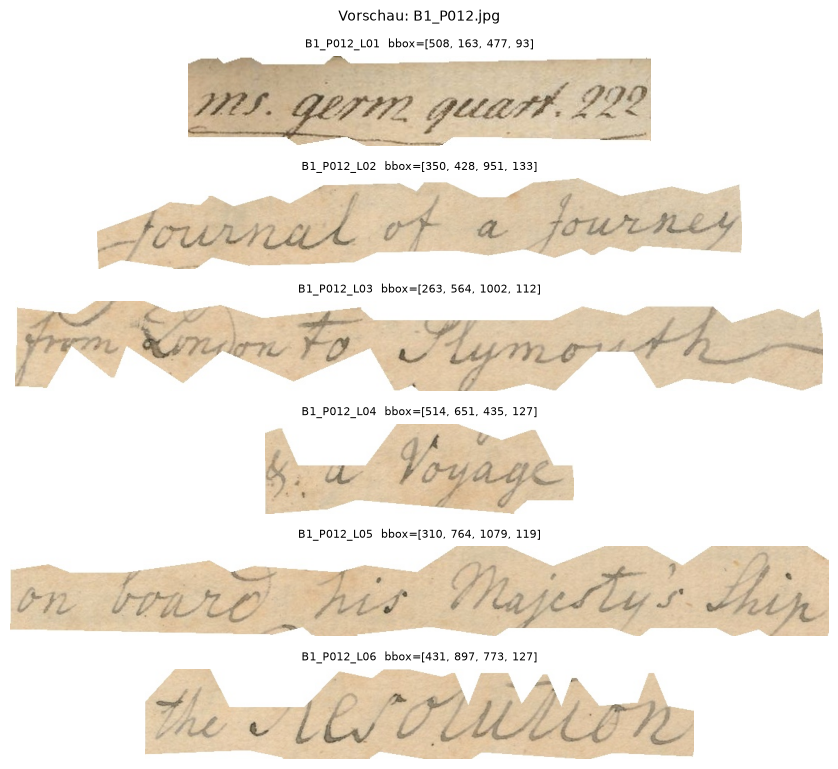

In [7]:
# Vorschau: erste 6 Zeilenbilder einer Beispielseite
sample_manifest_path = MANIFEST_DIR / f"{JPEG_FILES[0].stem}.json"
if sample_manifest_path.exists():
    with open(sample_manifest_path) as f:
        pm = json.load(f)
    preview_lines = pm['lines'][:6]
    if preview_lines:
        fig, axes = plt.subplots(len(preview_lines), 1, figsize=(14, len(preview_lines) * 1.3))
        if len(preview_lines) == 1:
            axes = [axes]
        for ax, rec in zip(axes, preview_lines):
            img = Image.open(REPO_ROOT / rec['line_image'])
            ax.imshow(img)
            ax.set_title(f"{rec['line_id']}  bbox={rec['bbox']}", fontsize=8)
            ax.axis('off')
        plt.suptitle(f"Vorschau: {JPEG_FILES[0].name}", fontsize=10)
        plt.tight_layout()
        plt.show()